<a href="https://colab.research.google.com/github/AquilaITOH/MedicalDataScience-exercises/blob/main/perceptron_iris_animation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# パーセプトロン学習アニメーション（Iris データセット）

Iris データセットの2次元特徴量（花びら長さ・幅）を使い、  
パーセプトロンの学習に伴う決定境界の変化を GIF アニメで可視化します。

In [1]:
# ── ライブラリのインストール（Colab では pillow はプリインストール済みだが念のため）
!pip install -q pillow

In [2]:
# ── インポート
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Colab でアニメを保存する際に必要
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
from IPython.display import Image, display

from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
# ── データ読み込み
iris_data = datasets.load_iris()
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris_df['species'] = iris_data.target_names[iris_data.target]
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [4]:
# ── 特徴量選択（selected_features の番号だけ変えれば全体に反映）
# 0: sepal length, 1: sepal width, 2: petal length, 3: petal width
feature_names = iris_data.feature_names
selected_features = [2, 3]  # petal length & petal width

X = iris_data.data[:, selected_features]
y = iris_data.target

xlabel_str = feature_names[selected_features[0]] + ' [standardized]'
ylabel_str = feature_names[selected_features[1]] + ' [standardized]'
print(f'使用特徴量: {feature_names[selected_features[0]]}  /  {feature_names[selected_features[1]]}')

使用特徴量: petal length (cm)  /  petal width (cm)


In [5]:
# ── 訓練・テスト分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y)

# ── 標準化
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std  = sc.transform(X_test)

In [6]:
# ── partial_fit でエポックごとに重みを保存しながら学習
N_EPOCHS = 30
classes  = np.unique(y_train)

ppn = Perceptron(tol=None, eta0=0.1, random_state=1234)

weights_per_epoch = []  # (coef_, intercept_) のコピーを格納
errors_per_epoch  = []

for epoch in range(N_EPOCHS):
    ppn.partial_fit(X_train_std, y_train, classes=classes)
    weights_per_epoch.append(
        (ppn.coef_.copy(), ppn.intercept_.copy())
    )
    n_errors = (y_train != ppn.predict(X_train_std)).sum()
    errors_per_epoch.append(n_errors)

print('訓練完了')
print(f'最終エポック 訓練誤分類数: {errors_per_epoch[-1]}')
print(f'テスト正答率: {accuracy_score(y_test, ppn.predict(X_test_std)):.2f}')

訓練完了
最終エポック 訓練誤分類数: 9
テスト正答率: 0.93


In [7]:
# ── GIF アニメーション生成
MARKERS = ('s', 'x', 'o', '^', 'v')
COLORS  = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
cmap    = ListedColormap(COLORS[:len(classes)])

X_combined = np.vstack((X_train_std, X_test_std))
y_combined  = np.hstack((y_train, y_test))
test_start  = len(X_train_std)  # テストサンプルの開始インデックス

# メッシュグリッド（決定領域の塗り分け用）
RESOLUTION = 0.02
x1_min, x1_max = X_combined[:, 0].min() - 1, X_combined[:, 0].max() + 1
x2_min, x2_max = X_combined[:, 1].min() - 1, X_combined[:, 1].max() + 1
xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, RESOLUTION),
    np.arange(x2_min, x2_max, RESOLUTION)
)
grid = np.c_[xx1.ravel(), xx2.ravel()]

# Figure
fig, (ax_map, ax_err) = plt.subplots(
    1, 2, figsize=(12, 5),
    gridspec_kw={'width_ratios': [3, 2]}
)

def update(epoch):
    ax_map.cla()
    ax_err.cla()

    # 重みを当該エポックの状態に戻す
    ppn.coef_      = weights_per_epoch[epoch][0]
    ppn.intercept_ = weights_per_epoch[epoch][1]

    # ---- 左パネル: 決定境界 ----
    Z = ppn.predict(grid).reshape(xx1.shape)
    ax_map.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    ax_map.set_xlim(xx1.min(), xx1.max())
    ax_map.set_ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y_combined)):
        mask = y_combined == cl
        ax_map.scatter(
            X_combined[mask, 0], X_combined[mask, 1],
            alpha=0.8, c=COLORS[idx],
            marker=MARKERS[idx], label=f'class {cl}',
            edgecolor='black', s=40
        )

    # テストサンプルを黒枠の丸で強調
    ax_map.scatter(
        X_combined[test_start:, 0], X_combined[test_start:, 1],
        facecolor='none', edgecolor='black',
        linewidth=1.2, marker='o', s=120, label='test set'
    )

    ax_map.set_xlabel(xlabel_str)
    ax_map.set_ylabel(ylabel_str)
    ax_map.set_title(
        f'Epoch {epoch + 1:02d} / {N_EPOCHS}   '
        f'train misclassifications: {errors_per_epoch[epoch]}'
    )
    ax_map.legend(loc='upper left', fontsize=8)

    # ---- 右パネル: 誤分類数の推移 ----
    ax_err.plot(
        range(1, epoch + 2), errors_per_epoch[:epoch + 1],
        marker='o', markersize=4, color='steelblue', linewidth=1.5
    )
    ax_err.axvline(epoch + 1, color='tomato', linestyle='--', linewidth=1.2)
    ax_err.set_xlim(1, N_EPOCHS)
    ax_err.set_ylim(-1, max(errors_per_epoch) + 3)
    ax_err.set_xlabel('Epoch')
    ax_err.set_ylabel('# misclassifications (train)')
    ax_err.set_title('Learning curve')
    ax_err.grid(True, alpha=0.4)

    fig.tight_layout()

ani = animation.FuncAnimation(
    fig, update,
    frames=N_EPOCHS,
    interval=500,  # ms/frame（変更可）
    repeat=True
)

GIF_PATH = 'perceptron_iris.gif'
ani.save(GIF_PATH, writer='pillow', dpi=100)
plt.close()
print(f'保存完了: {GIF_PATH}')

/tmp/ipykernel_41319/3898408957.py:42: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_map.scatter(
/tmp/ipykernel_41319/3898408957.py:42: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_map.scatter(
/tmp/ipykernel_41319/3898408957.py:42: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_map.scatter(
/tmp/ipykernel_41319/3898408957.py:42: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_map.scatter(


保存完了: perceptron_iris.gif


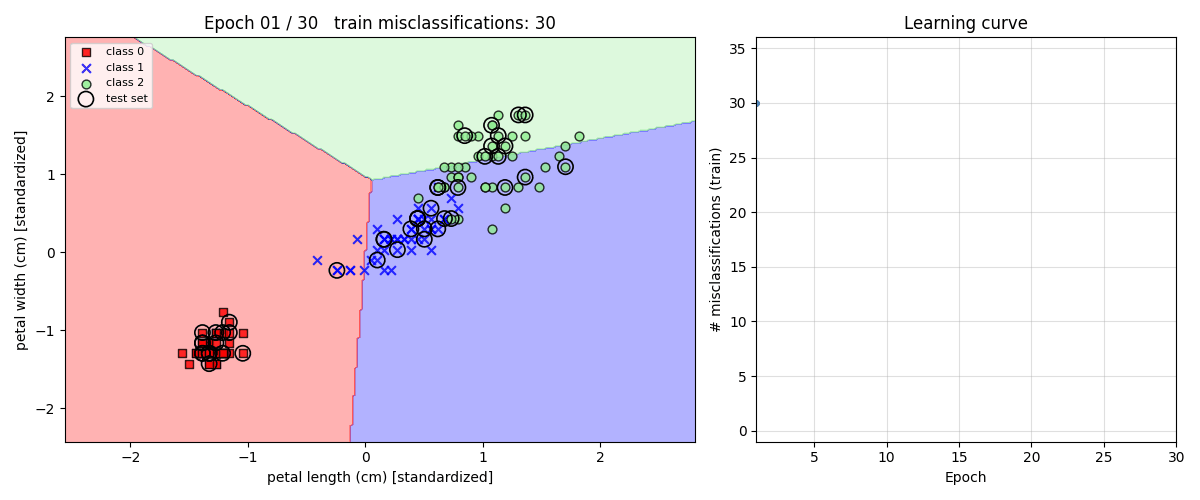

In [8]:
# ── Colab 上で GIF をインライン表示
display(Image(filename=GIF_PATH))

In [9]:
# ── （オプション）Google Drive にコピーして保存
from google.colab import drive
import shutil
drive.mount('/content/drive')
shutil.copy(GIF_PATH, '/content/drive/MyDrive/perceptron_iris.gif')
print('Drive に保存しました')

Mounted at /content/drive
Drive に保存しました
